# Extreme Event Analysis

In [98]:
# Import libraries
import pandas as pd
from scipy import stats
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


In [99]:
from src.common import mpl_apply
mpl_apply()

In [100]:
filepath = "../data/dtr_dataset.csv"
df = pd.read_csv(filepath)
df.head(3)

,x,y,STATION_NAME,CLIMATE_IDENTIFIER,ID,LOCAL_DATE,PROVINCE_CODE,LOCAL_YEAR,LOCAL_MONTH,LOCAL_DAY,...,HEATING_DEGREE_DAYS,HEATING_DEGREE_DAYS_FLAG,MIN_REL_HUMIDITY,MIN_REL_HUMIDITY_FLAG,MAX_REL_HUMIDITY,MAX_REL_HUMIDITY_FLAG,date,DTR,month,month_name
0,-52.783339,47.513356,ST JOHNS WEST CLIMATE,8403603,8403603.2010.8.24,2010-08-24 00:00:00,NL,2010,8,24,...,NaN,M,NaN,NaN,NaN,NaN,2010-08-24,NaN,8,Aug
1,-52.783339,47.513356,ST JOHNS WEST CLIMATE,8403603,8403603.2010.8.25,2010-08-25 00:00:00,NL,2010,8,25,...,0.6,NaN,49.0,NaN,96.0,NaN,2010-08-25,12.1,8,Aug
2,-52.783339,47.513356,ST JOHNS WEST CLIMATE,8403603,8403603.2010.8.26,2010-08-26 00:00:00,NL,2010,8,26,...,0.1,NaN,64.0,NaN,98.0,NaN,2010-08-26,8.1,8,Aug


In [101]:
df.columns

Index(['x', 'y', 'STATION_NAME', 'CLIMATE_IDENTIFIER', 'ID', 'LOCAL_DATE',
       'PROVINCE_CODE', 'LOCAL_YEAR', 'LOCAL_MONTH', 'LOCAL_DAY',
       'MEAN_TEMPERATURE', 'MEAN_TEMPERATURE_FLAG', 'MIN_TEMPERATURE',
       'MIN_TEMPERATURE_FLAG', 'MAX_TEMPERATURE', 'MAX_TEMPERATURE_FLAG',
       'TOTAL_PRECIPITATION', 'TOTAL_PRECIPITATION_FLAG', 'TOTAL_RAIN',
       'TOTAL_RAIN_FLAG', 'TOTAL_SNOW', 'TOTAL_SNOW_FLAG', 'SNOW_ON_GROUND',
       'SNOW_ON_GROUND_FLAG', 'DIRECTION_MAX_GUST', 'DIRECTION_MAX_GUST_FLAG',
       'SPEED_MAX_GUST', 'SPEED_MAX_GUST_FLAG', 'COOLING_DEGREE_DAYS',
       'COOLING_DEGREE_DAYS_FLAG', 'HEATING_DEGREE_DAYS',
       'HEATING_DEGREE_DAYS_FLAG', 'MIN_REL_HUMIDITY', 'MIN_REL_HUMIDITY_FLAG',
       'MAX_REL_HUMIDITY', 'MAX_REL_HUMIDITY_FLAG', 'date', 'DTR', 'month',
       'month_name'],
      dtype='object')

In [102]:
max_dtr = df[df.DTR == df.DTR.max()].iloc[0]
print(f"Max DTR: {max_dtr['DTR']}\n")

for col in max_dtr.index:
    print(f"{col}: {max_dtr[col]}")

Max DTR: 23.9

x: -52.78333888888889
y: 47.51335555555555
STATION_NAME: ST JOHNS WEST CLIMATE
CLIMATE_IDENTIFIER: 8403603
ID: 8403603.2017.2.8
LOCAL_DATE: 2017-02-08 00:00:00
PROVINCE_CODE: NL
LOCAL_YEAR: 2017
LOCAL_MONTH: 2
LOCAL_DAY: 8
MEAN_TEMPERATURE: -6.1
MEAN_TEMPERATURE_FLAG: nan
MIN_TEMPERATURE: -18.0
MIN_TEMPERATURE_FLAG: nan
MAX_TEMPERATURE: 5.9
MAX_TEMPERATURE_FLAG: nan
TOTAL_PRECIPITATION: 7.4
TOTAL_PRECIPITATION_FLAG: nan
TOTAL_RAIN: nan
TOTAL_RAIN_FLAG: M
TOTAL_SNOW: nan
TOTAL_SNOW_FLAG: M
SNOW_ON_GROUND: 31.0
SNOW_ON_GROUND_FLAG: nan
DIRECTION_MAX_GUST: 19.0
DIRECTION_MAX_GUST_FLAG: nan
SPEED_MAX_GUST: 54.0
SPEED_MAX_GUST_FLAG: nan
COOLING_DEGREE_DAYS: 0.0
COOLING_DEGREE_DAYS_FLAG: nan
HEATING_DEGREE_DAYS: 24.1
HEATING_DEGREE_DAYS_FLAG: nan
MIN_REL_HUMIDITY: nan
MIN_REL_HUMIDITY_FLAG: nan
MAX_REL_HUMIDITY: nan
MAX_REL_HUMIDITY_FLAG: nan
date: 2017-02-08
DTR: 23.9
month: 2
month_name: Feb


In [103]:
min_dtr = df[df.DTR == df.DTR.min()].iloc[0]
print(f"Min DTR: {min_dtr['DTR']}\n")

for col in min_dtr.index:
    print(f"{col}: {min_dtr[col]}")

Min DTR: 0.2

x: -52.78333888888889
y: 47.51335555555555
STATION_NAME: ST JOHNS WEST CLIMATE
CLIMATE_IDENTIFIER: 8403603
ID: 8403603.2024.2.15
LOCAL_DATE: 2024-02-15 00:00:00
PROVINCE_CODE: NL
LOCAL_YEAR: 2024
LOCAL_MONTH: 2
LOCAL_DAY: 15
MEAN_TEMPERATURE: 0.1
MEAN_TEMPERATURE_FLAG: nan
MIN_TEMPERATURE: 0.0
MIN_TEMPERATURE_FLAG: nan
MAX_TEMPERATURE: 0.2
MAX_TEMPERATURE_FLAG: nan
TOTAL_PRECIPITATION: 23.2
TOTAL_PRECIPITATION_FLAG: nan
TOTAL_RAIN: nan
TOTAL_RAIN_FLAG: nan
TOTAL_SNOW: nan
TOTAL_SNOW_FLAG: nan
SNOW_ON_GROUND: 23.0
SNOW_ON_GROUND_FLAG: nan
DIRECTION_MAX_GUST: 33.0
DIRECTION_MAX_GUST_FLAG: nan
SPEED_MAX_GUST: 66.0
SPEED_MAX_GUST_FLAG: nan
COOLING_DEGREE_DAYS: 0.0
COOLING_DEGREE_DAYS_FLAG: nan
HEATING_DEGREE_DAYS: 17.9
HEATING_DEGREE_DAYS_FLAG: nan
MIN_REL_HUMIDITY: 97.0
MIN_REL_HUMIDITY_FLAG: nan
MAX_REL_HUMIDITY: 100.0
MAX_REL_HUMIDITY_FLAG: nan
date: 2024-02-15
DTR: 0.2
month: 2
month_name: Feb


In [104]:
df[["STATION_NAME", "MAX_TEMPERATURE", "MIN_TEMPERATURE", "LOCAL_MONTH", 'LOCAL_YEAR']][df.DTR >= 20].tail(30)

,STATION_NAME,MAX_TEMPERATURE,MIN_TEMPERATURE,LOCAL_MONTH,LOCAL_YEAR
1588,ST JOHNS WEST CLIMATE,3.1,-18.1,1,2015
2115,ST JOHNS WEST CLIMATE,22.7,1.8,6,2016
2349,ST JOHNS WEST CLIMATE,5.9,-18.0,2,2017
3930,ST JOHNS WEST CLIMATE,28.3,7.1,6,2021
4268,ST JOHNS WEST CLIMATE,20.5,-0.1,5,2022


#### Extreme high-DTR

In [105]:
# Calculate 90th percentile threshold
dtr_90th = df['DTR'].quantile(0.9)
print(f"90th percentile DTR threshold: {dtr_90th:.2f}")

# Define high-DTR extreme days
df['high_dtr_extreme'] = df['DTR'] > dtr_90th

# Summary
print(f"\nTotal high-DTR extreme days: {df['high_dtr_extreme'].sum()}")
print(f"Percentage of dataset: {(df['high_dtr_extreme'].sum() / len(df) * 100):.2f}%")

90th percentile DTR threshold: 13.07

Total high-DTR extreme days: 546
Percentage of dataset: 9.81%


In [106]:
df[df['high_dtr_extreme']][['date', 'DTR', 'MAX_TEMPERATURE', 'MIN_TEMPERATURE']]

,date,DTR,MAX_TEMPERATURE,MIN_TEMPERATURE
6,2010-08-30,14.0,22.8,8.8
26,2010-09-19,13.5,18.4,4.9
34,2010-09-27,15.5,15.2,-0.3
77,2010-11-09,13.9,16.8,2.9
81,2010-11-13,14.2,12.2,-2.0
...,...,...,...,...
5508,2025-10-03,14.0,17.6,3.6
5511,2025-10-06,15.3,14.4,-0.9
5514,2025-10-09,15.0,20.2,5.2
5526,2025-10-21,13.2,13.4,0.2


In [107]:
# Calculate 10th percentile threshold
dtr_10th = df['DTR'].quantile(0.1)
print(f"10th percentile DTR threshold: {dtr_10th:.2f}")

# Define high-DTR extreme days
df['low_dtr_extreme'] = df['DTR'] < dtr_10th

# Print
print(f"\nTotal low-DTR extreme days: {df['low_dtr_extreme'].sum()}")
print(f"Percentage of dataset: {(df['low_dtr_extreme'].sum() / len(df) * 100):.2f}%")

10th percentile DTR threshold: 3.10

Total low-DTR extreme days: 543
Percentage of dataset: 9.75%


In [108]:
# Ensure date column is datetime
df['date'] = pd.to_datetime(df['date'])

# Count high and low extreme days per year
high_per_year = df[df['high_dtr_extreme']].groupby(df['date'].dt.year).size()
low_per_year = df[df['low_dtr_extreme']].groupby(df['date'].dt.year).size()

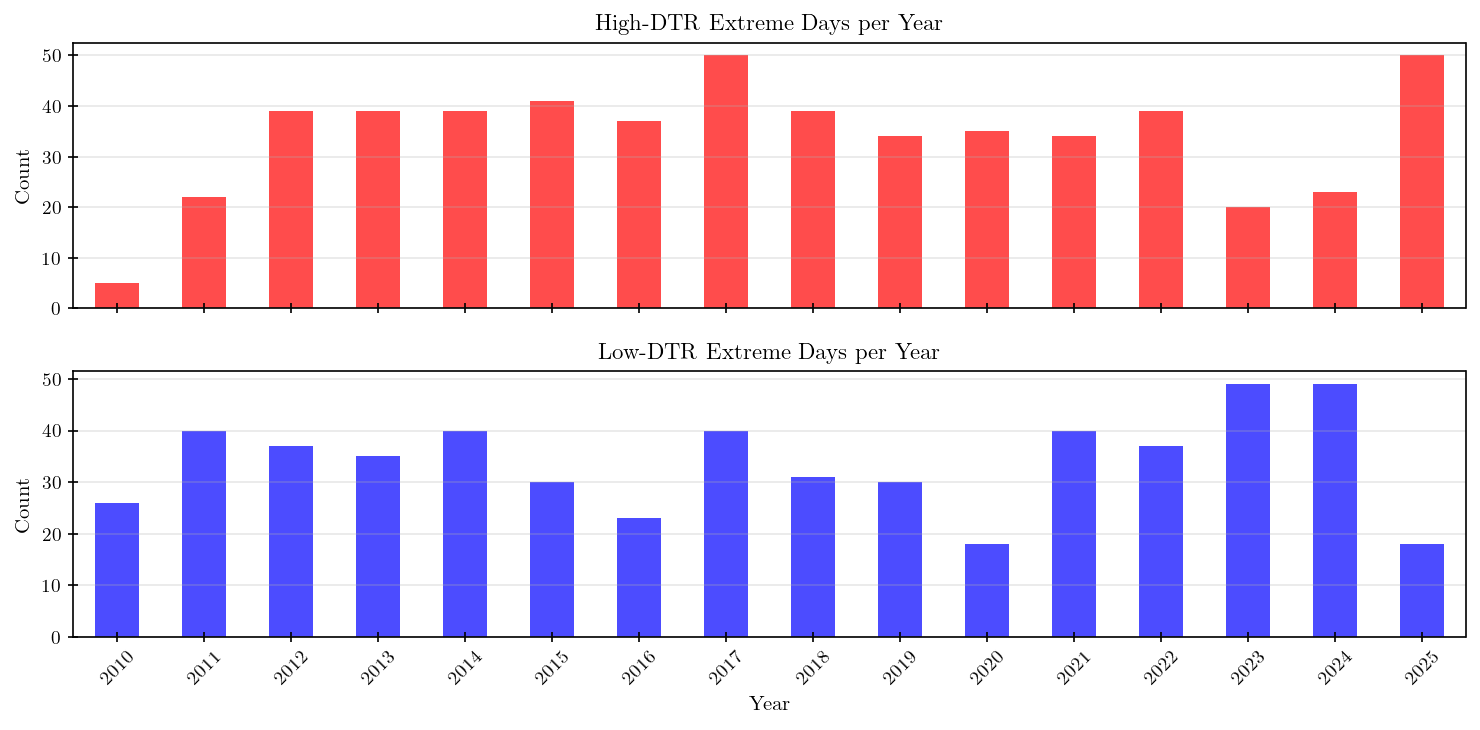

In [109]:
# Ensure date column is datetime
df['date'] = pd.to_datetime(df['date'])

# Count high and low extreme days per year
high_per_year = df[df['high_dtr_extreme']].groupby(df['date'].dt.year).size()
low_per_year = df[df['low_dtr_extreme']].groupby(df['date'].dt.year).size()

# Create subplots
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

# Plot high-DTR extremes
high_per_year.plot(kind='bar', color='red', alpha=0.7, ax=axes[0])
axes[0].set_title('High-DTR Extreme Days per Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Count')
axes[0].grid(axis='y', alpha=0.3)

# Plot low-DTR extremes
low_per_year.plot(kind='bar', color='blue', alpha=0.7, ax=axes[1])
axes[1].set_title('Low-DTR Extreme Days per Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Count')
axes[1].grid(axis='y', alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("../plots/dtr_extremes_per_year.pdf", dpi=300)

## Trend Testing

#### Extreme DTR Trends?

In [110]:
# Ensure date is datetime
df['date'] = pd.to_datetime(df['date'])

# Count high and low extreme days per year
high_per_year = df[df['high_dtr_extreme']].groupby(df['date'].dt.year).size()
low_per_year = df[df['low_dtr_extreme']].groupby(df['date'].dt.year).size()

# Prepare data for regression
years = high_per_year.index.values
high_counts = high_per_year.values
low_counts = low_per_year.values

# Linear regression for high extremes
slope_high, intercept_high, r_value_high, p_value_high, std_err_high = stats.linregress(years, high_counts)

# Linear regression for low extremes
slope_low, intercept_low, r_value_low, p_value_low, std_err_low = stats.linregress(years, low_counts)

# Calculate 95% confidence intervals
ci_high = 1.96 * std_err_high
ci_low = 1.96 * std_err_low

# Print results
print("HIGH-DTR EXTREMES:")
print(f"  Slope: {slope_high:.4f} days/year")
print(f"  95% CI: [{slope_high - ci_high:.4f}, {slope_high + ci_high:.4f}]")
print(f"  p-value: {p_value_high:.4f}")
print(f"  R²: {r_value_high**2:.4f}\n")

print("LOW-DTR EXTREMES:")
print(f"  Slope: {slope_low:.4f} days/year")
print(f"  95% CI: [{slope_low - ci_low:.4f}, {slope_low + ci_low:.4f}]")
print(f"  p-value: {p_value_low:.4f}")
print(f"  R²: {r_value_low**2:.4f}")


HIGH-DTR EXTREMES:
  Slope: 0.5794 days/year
  95% CI: [-0.6535, 1.8124]
  p-value: 0.3726
  R²: 0.0571

LOW-DTR EXTREMES:
  Slope: 0.1456 days/year
  95% CI: [-0.8958, 1.1870]
  p-value: 0.7881
  R²: 0.0053


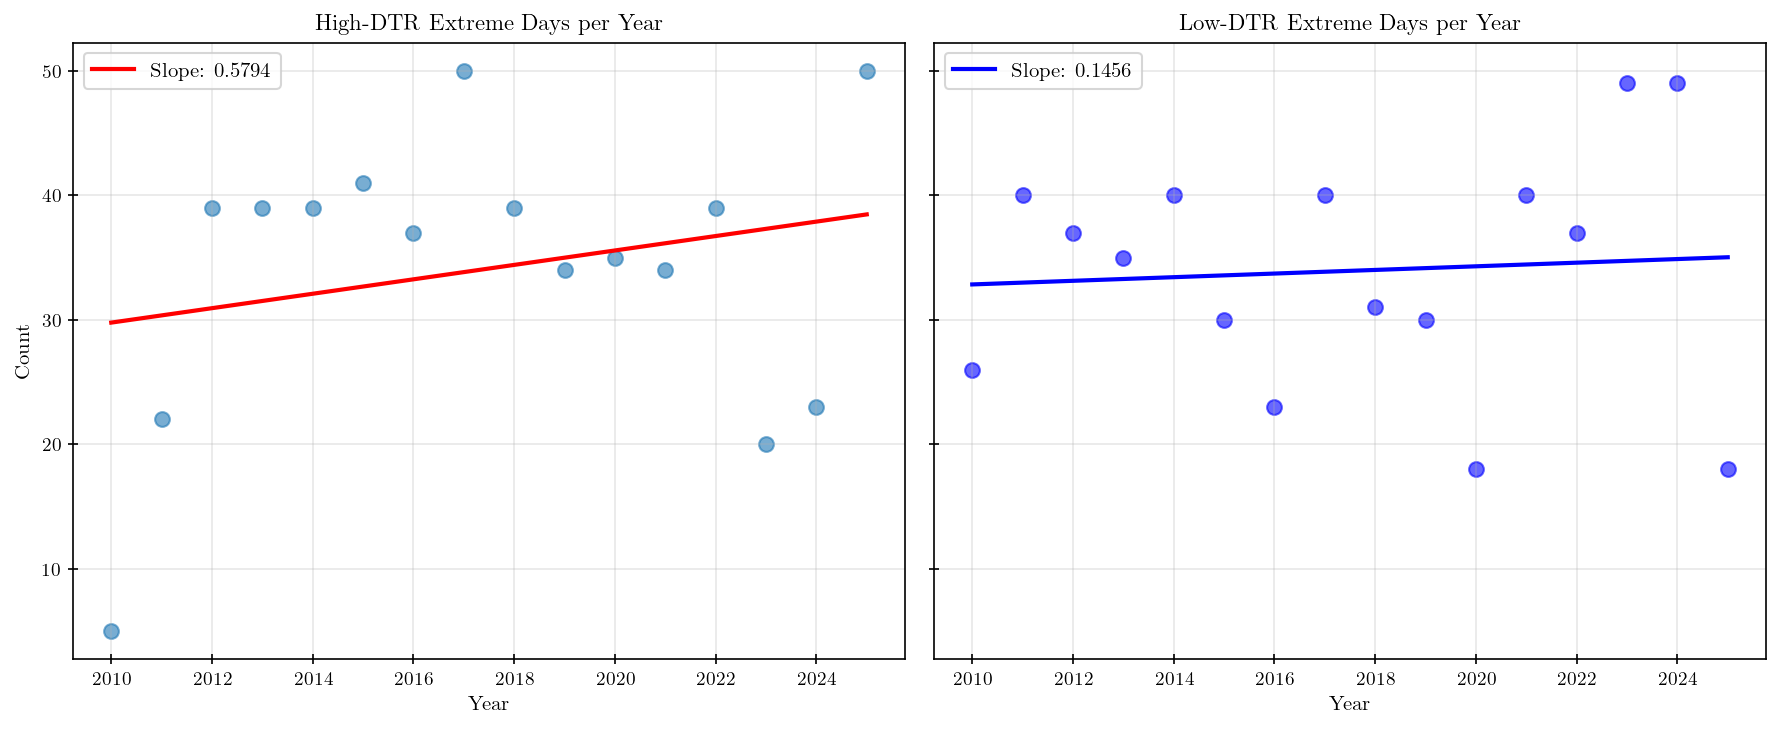

In [115]:
# Plot with regression lines
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# High extremes
axes[0].scatter(years, high_counts, alpha=0.6, s=50)
axes[0].plot(years, slope_high * years + intercept_high, 'r-', linewidth=2, label=f'Slope: {slope_high:.4f}')
axes[0].set_title('High-DTR Extreme Days per Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Count')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Low extremes
axes[1].scatter(years, low_counts, alpha=0.6, s=50, color='blue')
axes[1].plot(years, slope_low * years + intercept_low, 'b-', linewidth=2, label=f'Slope: {slope_low:.4f}')
axes[1].set_title('Low-DTR Extreme Days per Year')
axes[1].set_xlabel('Year')
# axes[1].set_ylabel('Count')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.savefig("../plots/extreme_trends.pdf", dpi=300)

#### Mann-Kendall tests

**Annual mean DTR**

Null Hypothesis: No monotonic trend exists.  
Alternate Hypothesis: One-sided monotonic trend exists (increasing trend)

A monotonic trend is one that consistently moves in a single direction either always increasing or always decreasing—without reversing.

MANN-KENDALL TEST: Annual Mean DTR (2000–2025)
Null hypothesis (H₀): No monotonic trend in DTR
Alternative hypothesis (H₁): Monotonic increasing trend

Kendall's τ: 0.1333
p-value (two-sided): 0.5056
p-value (one-sided, increasing): 0.2528
Significance level: α = 0.05

✗ FAIL TO REJECT null hypothesis
  Conclusion: No statistically significant monotonic trend (α=0.05).
  Random fluctuations dominate; no systematic directional change.


INTERPRETATION
Kendall's τ = 0.1333 (positive): Weak tendency toward increasing DTR

One-sided p-value = 0.2528:
  → This trend is NOT statistically significant at α=0.05
  → Cannot reject the null hypothesis of no monotonic trend


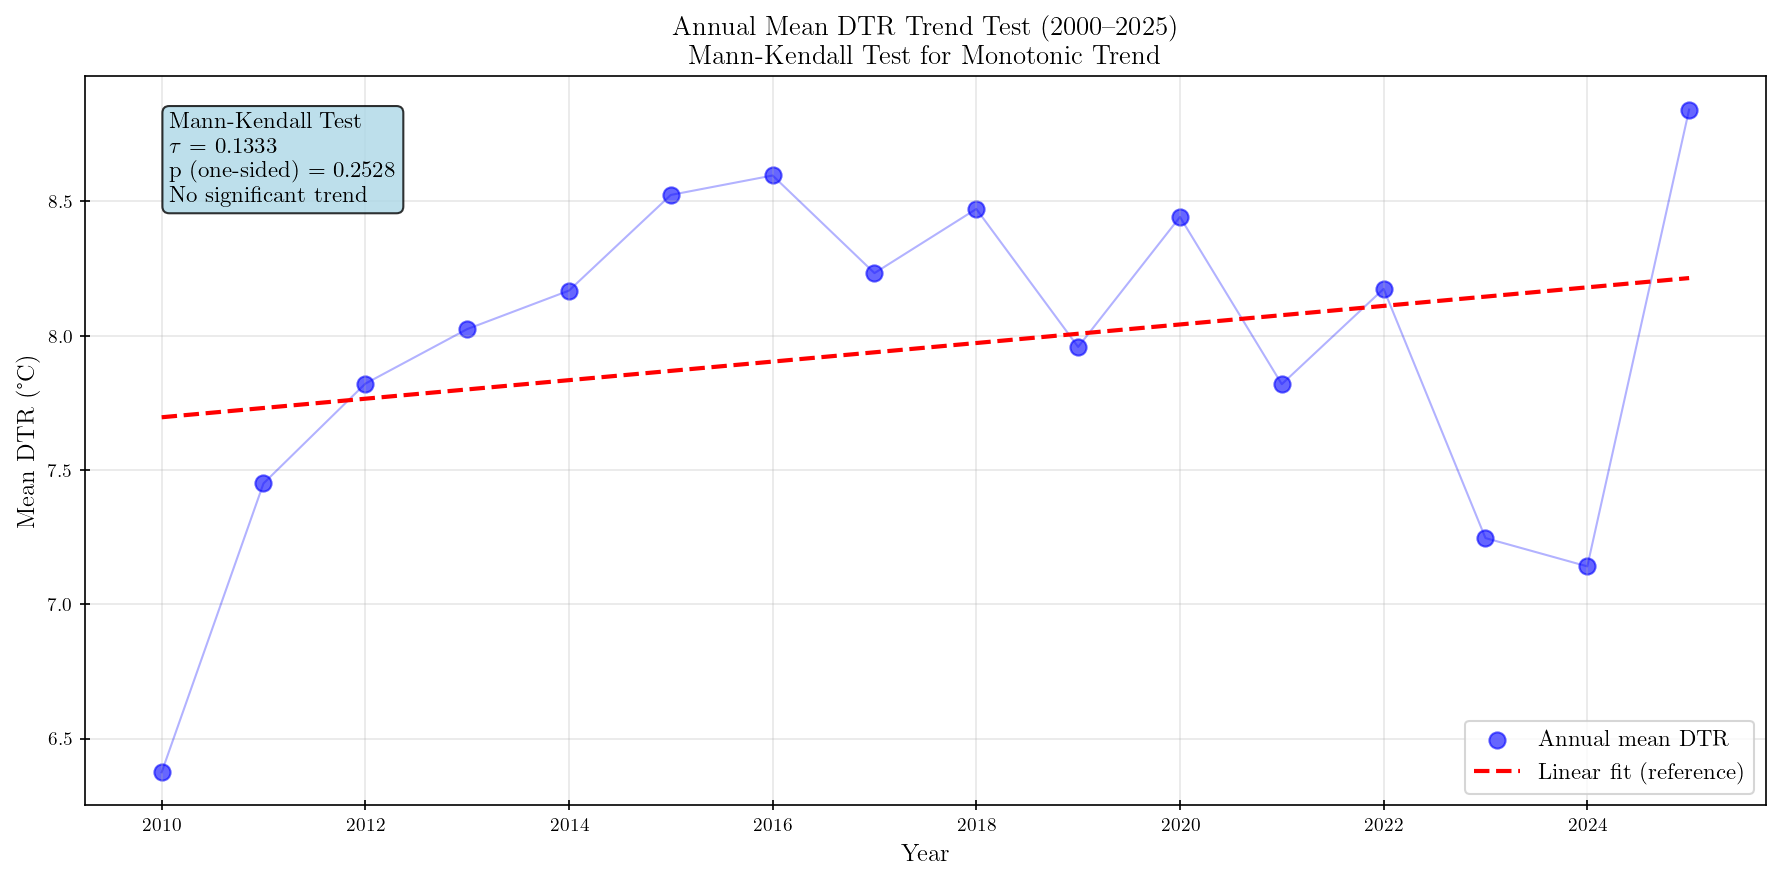

In [119]:
from scipy.stats import kendalltau
import numpy as np

# Ensure date is datetime
df['date'] = pd.to_datetime(df['date'])

# Compute annual mean DTR
annual_dtr = df.groupby(df['date'].dt.year)['DTR'].mean()
years = annual_dtr.index.values
dtr_values = annual_dtr.values

# ============================================================================
# MANN-KENDALL TEST FOR ANNUAL MEAN DTR
# ============================================================================
tau, p_value_two_sided = kendalltau(years, dtr_values)

# Convert to one-sided p-value (testing for increasing trend)
p_value_one_sided = p_value_two_sided / 2

print("="*70)
print("MANN-KENDALL TEST: Annual Mean DTR (2000–2025)")
print("="*70)
print(f"Null hypothesis (H₀): No monotonic trend in DTR")
print(f"Alternative hypothesis (H₁): Monotonic increasing trend\n")
print(f"Kendall's τ: {tau:.4f}")
print(f"p-value (two-sided): {p_value_two_sided:.4f}")
print(f"p-value (one-sided, increasing): {p_value_one_sided:.4f}")
print(f"Significance level: α = 0.05\n")

if p_value_one_sided < 0.05:
    print("✓ REJECT null hypothesis")
    if tau > 0:
        print(f"  Conclusion: Statistically significant INCREASING monotonic trend detected.")
    else:
        print(f"  Conclusion: Statistically significant DECREASING monotonic trend detected.")
else:
    print("✗ FAIL TO REJECT null hypothesis")
    print(f"  Conclusion: No statistically significant monotonic trend (α=0.05).")
    print(f"  Random fluctuations dominate; no systematic directional change.\n")

# ============================================================================
# INTERPRETATION
# ============================================================================
print("\n" + "="*70)
print("INTERPRETATION")
print("="*70)
if tau > 0:
    print(f"Kendall's τ = {tau:.4f} (positive): Weak tendency toward increasing DTR")
else:
    print(f"Kendall's τ = {tau:.4f} (negative): Weak tendency toward decreasing DTR")

print(f"\nOne-sided p-value = {p_value_one_sided:.4f}:")
if p_value_one_sided < 0.05:
    print(f"  → This trend is statistically significant at α=0.05")
    if tau > 0:
        print(f"  → INCONSISTENT with global warming theory (DTR should decline)")
    else:
        print(f"  → CONSISTENT with global warming theory (DTR declining with warming)")
else:
    print(f"  → This trend is NOT statistically significant at α=0.05")
    print(f"  → Cannot reject the null hypothesis of no monotonic trend")

# ============================================================================
# VISUALIZATION
# ============================================================================
fig, ax = plt.subplots(figsize=(12, 6))

ax.scatter(years, dtr_values, s=60, alpha=0.6, color='blue', label='Annual mean DTR')
ax.plot(years, dtr_values, 'b-', alpha=0.3, linewidth=1)

# Add trend line (for reference, not from Mann-Kendall)
z = np.polyfit(years, dtr_values, 1)
p = np.poly1d(z)
ax.plot(years, p(years), 'r--', linewidth=2, label='Linear fit (reference)')

# Annotation box
textstr = f'Mann-Kendall Test\n $\\tau$ = {tau:.4f}\np (one-sided) = {p_value_one_sided:.4f}'
if p_value_one_sided < 0.05:
    result = "Significant trend"
    box_color = 'lightcoral'
else:
    result = "No significant trend"
    box_color = 'lightblue'

textstr += f'\n{result}'
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor=box_color, alpha=0.8))

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Mean DTR (°C)', fontsize=12)
ax.set_title('Annual Mean DTR Trend Test (2000–2025)\nMann-Kendall Test for Monotonic Trend', fontsize=13)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig("../plots/mann_kendall_annual_dtr.pdf", dpi=300)
plt.show()

**High-extreme and low-extreme annual DTR counts**

Null Hypothesis: No monotonic trend exists.  
Alternate Hypothesis: One-sided monotonic trend exists (increasing trend)

Apply Mann-Kendall test separately to high-extreme and low-extreme annual counts.

In [121]:
from scipy.stats import kendalltau
import numpy as np

# Ensure date is datetime
df['date'] = pd.to_datetime(df['date'])

# Count high and low extreme days per year
high_per_year = df[df['high_dtr_extreme']].groupby(df['date'].dt.year).size()
low_per_year = df[df['low_dtr_extreme']].groupby(df['date'].dt.year).size()

years = high_per_year.index.values
high_counts = high_per_year.values
low_counts = low_per_year.values

# ============================================================================
# MANN-KENDALL TEST: HIGH-DTR EXTREMES
# ============================================================================
tau_high, p_value_high_two_sided = kendalltau(years, high_counts)
p_value_high_one_sided = p_value_high_two_sided / 2

print("="*70)
print("MANN-KENDALL TEST: High-DTR Extreme Days Annual Count (2000–2025)")
print("="*70)
print(f"Null hypothesis (H₀): No monotonic trend in high-DTR extremes")
print(f"Alternative hypothesis (H₁): Monotonic increasing trend\n")
print(f"Kendall's τ: {tau_high:.4f}")
print(f"p-value (two-sided): {p_value_high_two_sided:.4f}")
print(f"p-value (one-sided, increasing): {p_value_high_one_sided:.4f}")
print(f"Significance level: α = 0.05\n")

if p_value_high_one_sided < 0.05:
    print("✓ REJECT null hypothesis")
    if tau_high > 0:
        print(f"  Conclusion: Statistically significant INCREASING trend in high-DTR extremes.")
    else:
        print(f"  Conclusion: Statistically significant DECREASING trend in high-DTR extremes.")
else:
    print("✗ FAIL TO REJECT null hypothesis")
    print(f"  Conclusion: No statistically significant monotonic trend in high-DTR extremes.\n")

# ============================================================================
# MANN-KENDALL TEST: LOW-DTR EXTREMES
# ============================================================================
tau_low, p_value_low_two_sided = kendalltau(years, low_counts)
p_value_low_one_sided = p_value_low_two_sided / 2

print("\n" + "="*70)
print("MANN-KENDALL TEST: Low-DTR Extreme Days Annual Count (2000–2025)")
print("="*70)
print(f"Null hypothesis (H₀): No monotonic trend in low-DTR extremes")
print(f"Alternative hypothesis (H₁): Monotonic increasing trend\n")
print(f"Kendall's τ: {tau_low:.4f}")
print(f"p-value (two-sided): {p_value_low_two_sided:.4f}")
print(f"p-value (one-sided, increasing): {p_value_low_one_sided:.4f}")
print(f"Significance level: α = 0.05\n")

if p_value_low_one_sided < 0.05:
    print("✓ REJECT null hypothesis")
    if tau_low > 0:
        print(f"  Conclusion: Statistically significant INCREASING trend in low-DTR extremes.")
    else:
        print(f"  Conclusion: Statistically significant DECREASING trend in low-DTR extremes.")
else:
    print("✗ FAIL TO REJECT null hypothesis")
    print(f"  Conclusion: No statistically significant monotonic trend in low-DTR extremes.\n")

# ============================================================================
# SUMMARY TABLE
# ============================================================================
print("\n" + "="*70)
print("SUMMARY: Mann-Kendall Results for Extreme Days")
print("="*70)
summary_data = {
    'Extreme Type': ['High-DTR', 'Low-DTR'],
    'Kendall τ': [f'{tau_high:.4f}', f'{tau_low:.4f}'],
    'p-value (one-sided)': [f'{p_value_high_one_sided:.4f}', f'{p_value_low_one_sided:.4f}'],
    'Significant (α=0.05)': ['Yes' if p_value_high_one_sided < 0.05 else 'No',
                              'Yes' if p_value_low_one_sided < 0.05 else 'No'],
    'Trend Direction': ['Increasing' if tau_high > 0 else 'Decreasing',
                        'Increasing' if tau_low > 0 else 'Decreasing']
}

for key in summary_data:
    print(f"{key:.<25} {summary_data[key][0]:>15} {summary_data[key][1]:>15}")

# ============================================================================
# VISUALIZATION
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# HIGH-DTR EXTREMES
axes[0].scatter(years, high_counts, s=60, alpha=0.6, color='red', label='High-DTR extreme days')
axes[0].plot(years, high_counts, 'r-', alpha=0.3, linewidth=1)
z_high = np.polyfit(years, high_counts, 1)
p_high = np.poly1d(z_high)
axes[0].plot(years, p_high(years), 'r--', linewidth=2, label='Linear fit (reference)')

textstr_high = f'Mann-Kendall Test\nτ = {tau_high:.4f}\np (one-sided) = {p_value_high_one_sided:.4f}'
if p_value_high_one_sided < 0.05:
    result_high = "Significant trend"
    box_color_high = 'lightcoral'
else:
    result_high = "No significant trend"
    box_color_high = 'lightyellow'

textstr_high += f'\n{result_high}'
axes[0].text(0.05, 0.95, textstr_high, transform=axes[0].transAxes, fontsize=10,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor=box_color_high, alpha=0.8))

axes[0].set_xlabel('Year', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].set_title('High-DTR Extreme Days Trend\nMann-Kendall Test', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=10)

# LOW-DTR EXTREMES
axes[1].scatter(years, low_counts, s=60, alpha=0.6, color='blue', label='Low-DTR extreme days')
axes[1].plot(years, low_counts, 'b-', alpha=0.3, linewidth=1)
z_low = np.polyfit(years, low_counts, 1)
p_low = np.poly1d(z_low)
axes[1].plot(years, p_low(years), 'b--', linewidth=2, label='Linear fit (reference)')

textstr_low = f'Mann-Kendall Test\n $\\tau$ = {tau_low:.4f}\np (one-sided) = {p_value_low_one_sided:.4f}'
if p_value_low_one_sided < 0.05:
    result_low = "Significant trend"
    box_color_low = 'lightblue'
else:
    result_low = "No significant trend"
    box_color_low = 'lightyellow'

textstr_low += f'\n{result_low}'
axes[1].text(0.05, 0.95, textstr_low, transform=axes[1].transAxes, fontsize=10,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor=box_color_low, alpha=0.8))

axes[1].set_xlabel('Year', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].set_title('Low-DTR Extreme Days Trend\nMann-Kendall Test', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig("../plots/mann_kendall_extremes.pdf", dpi=300)
plt.show()

MANN-KENDALL TEST: High-DTR Extreme Days Annual Count (2000–2025)
Null hypothesis (H₀): No monotonic trend in high-DTR extremes
Alternative hypothesis (H₁): Monotonic increasing trend

Kendall's τ: 0.0176
p-value (two-sided): 0.9269
p-value (one-sided, increasing): 0.4634
Significance level: α = 0.05

✗ FAIL TO REJECT null hypothesis
  Conclusion: No statistically significant monotonic trend in high-DTR extremes.


MANN-KENDALL TEST: Low-DTR Extreme Days Annual Count (2000–2025)
Null hypothesis (H₀): No monotonic trend in low-DTR extremes
Alternative hypothesis (H₁): Monotonic increasing trend

Kendall's τ: 0.0522
p-value (two-sided): 0.7843
p-value (one-sided, increasing): 0.3922
Significance level: α = 0.05

✗ FAIL TO REJECT null hypothesis
  Conclusion: No statistically significant monotonic trend in low-DTR extremes.


SUMMARY: Mann-Kendall Results for Extreme Days
Extreme Type.............        High-DTR         Low-DTR
Kendall τ................          0.0176          0.0522
p-

RuntimeError: latex was not able to process the following string:
b'\\u03c4 = 0.0176'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error file.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.27 (TeX Live 2025) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./file.tex
LaTeX2e <2024-11-01> patch level 2
L3 programming layer <2025-01-18>
(/usr/local/texlive/2025basic/texmf-dist/tex/latex/base/article.cls
Document Class: article 2024/06/29 v1.4n Standard LaTeX document class
(/usr/local/texlive/2025basic/texmf-dist/tex/latex/base/size10.clo))
(/usr/local/texlive/2025basic/texmf-dist/tex/latex/type1cm/type1cm.sty)
(/usr/local/texlive/2025basic/texmf-dist/tex/latex/cm-super/type1ec.sty
(/usr/local/texlive/2025basic/texmf-dist/tex/latex/base/t1cmr.fd))
(/usr/local/texlive/2025basic/texmf-dist/tex/latex/base/inputenc.sty)
(/usr/local/texlive/2025basic/texmf-dist/tex/latex/geometry/geometry.sty
(/usr/local/texliv

Error in callback <function _draw_all_if_interactive at 0x11b4c5620> (for post_execute), with arguments args (),kwargs {}:


RuntimeError: latex was not able to process the following string:
b'\\u03c4 = 0.0176'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error file.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.27 (TeX Live 2025) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./file.tex
LaTeX2e <2024-11-01> patch level 2
L3 programming layer <2025-01-18>
(/usr/local/texlive/2025basic/texmf-dist/tex/latex/base/article.cls
Document Class: article 2024/06/29 v1.4n Standard LaTeX document class
(/usr/local/texlive/2025basic/texmf-dist/tex/latex/base/size10.clo))
(/usr/local/texlive/2025basic/texmf-dist/tex/latex/type1cm/type1cm.sty)
(/usr/local/texlive/2025basic/texmf-dist/tex/latex/cm-super/type1ec.sty
(/usr/local/texlive/2025basic/texmf-dist/tex/latex/base/t1cmr.fd))
(/usr/local/texlive/2025basic/texmf-dist/tex/latex/base/inputenc.sty)
(/usr/local/texlive/2025basic/texmf-dist/tex/latex/geometry/geometry.sty
(/usr/local/texliv

RuntimeError: latex was not able to process the following string:
b'\\u03c4 = 0.0176'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error file.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.27 (TeX Live 2025) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./file.tex
LaTeX2e <2024-11-01> patch level 2
L3 programming layer <2025-01-18>
(/usr/local/texlive/2025basic/texmf-dist/tex/latex/base/article.cls
Document Class: article 2024/06/29 v1.4n Standard LaTeX document class
(/usr/local/texlive/2025basic/texmf-dist/tex/latex/base/size10.clo))
(/usr/local/texlive/2025basic/texmf-dist/tex/latex/type1cm/type1cm.sty)
(/usr/local/texlive/2025basic/texmf-dist/tex/latex/cm-super/type1ec.sty
(/usr/local/texlive/2025basic/texmf-dist/tex/latex/base/t1cmr.fd))
(/usr/local/texlive/2025basic/texmf-dist/tex/latex/base/inputenc.sty)
(/usr/local/texlive/2025basic/texmf-dist/tex/latex/geometry/geometry.sty
(/usr/local/texliv

<Figure size 2100x900 with 2 Axes>